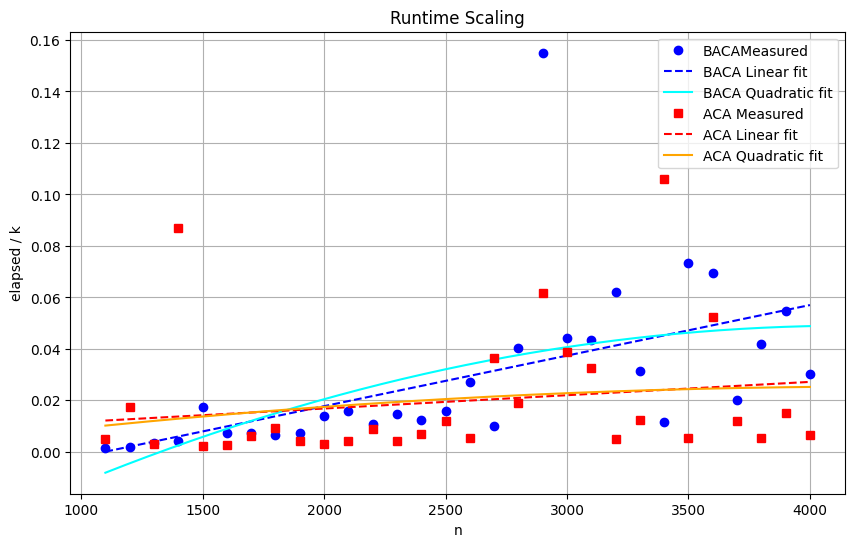

BACA Linear coefficients:
[ 1.96365490e-05 -2.15225679e-02]

BACA Quadratic coefficients:
[-6.04260083e-09  5.04538132e-05 -5.62876646e-02]

ACA Linear coefficients:
[5.17663378e-06 6.47709184e-03]

ACA Quadratic coefficients:
[-1.45258627e-09  1.25848238e-05 -1.88012118e-03]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# LOAD CSV DATA
# =========================================================

baca = pd.read_csv("baca_results.csv")
aca = pd.read_csv("aca_results.csv")

# =========================================================
# PREPARE FIGURE
# =========================================================

plt.figure(figsize=(12, 7))

# =========================================================
# UNIQUE d VALUES
# =========================================================

d_values = sorted(baca["d"].unique())

# =========================================================
# BACA PLOTS
# =========================================================

for d in d_values:

    # filter rows for current d
    df = baca[baca["d"] == d]

    # sort by n
    df = df.sort_values("n")

    # numpy arrays
    x = df["n"].to_numpy()

    elapsed = df["elapsed"].to_numpy()
    rank = df["rank"].to_numpy()

    # normalized runtime
    y = elapsed / rank

    # measured data
    plt.plot(
        x,
        y,
        'o',
        label=f'BACA d={d}'
    )

    # linear fit
    coeff_lin = np.polyfit(x, y, 1)
    fit_lin = np.poly1d(coeff_lin)

    # quadratic fit
    coeff_quad = np.polyfit(x, y, 2)
    fit_quad = np.poly1d(coeff_quad)

    x_fit = np.linspace(
        np.min(x),
        np.max(x),
        300
    )

    # linear fit curve
    plt.plot(
        x_fit,
        fit_lin(x_fit),
        '--',
        label=f'BACA d={d} linear'
    )

    # quadratic fit curve
    plt.plot(
        x_fit,
        fit_quad(x_fit),
        '-',
        alpha=0.7,
        label=f'BACA d={d} quadratic'
    )

    print("\n===================================")
    print(f"BACA d = {d}")
    print("===================================")

    print("Linear coefficients:")
    print(coeff_lin)

    print("\nQuadratic coefficients:")
    print(coeff_quad)

# =========================================================
# ACA PLOT
# =========================================================

aca = aca.sort_values("n")

x_aca = aca["n"].to_numpy()

elapsed_aca = aca["elapsed"].to_numpy()
rank_aca = aca["rank"].to_numpy()

y_aca = elapsed_aca / rank_aca

# measured ACA
plt.plot(
    x_aca,
    y_aca,
    'ks',
    label='ACA'
)

# ACA linear fit
coeff_lin_aca = np.polyfit(x_aca, y_aca, 1)
fit_lin_aca = np.poly1d(coeff_lin_aca)

# ACA quadratic fit
coeff_quad_aca = np.polyfit(x_aca, y_aca, 2)
fit_quad_aca = np.poly1d(coeff_quad_aca)

x_fit_aca = np.linspace(
    np.min(x_aca),
    np.max(x_aca),
    300
)

plt.plot(
    x_fit_aca,
    fit_lin_aca(x_fit_aca),
    'k--',
    label='ACA linear'
)

plt.plot(
    x_fit_aca,
    fit_quad_aca(x_fit_aca),
    'k-',
    alpha=0.7,
    label='ACA quadratic'
)

print("\n===================================")
print("ACA")
print("===================================")

print("Linear coefficients:")
print(coeff_lin_aca)

print("\nQuadratic coefficients:")
print(coeff_quad_aca)

# =========================================================
# FINALIZE PLOT
# =========================================================

plt.xlabel("n")
plt.ylabel("elapsed / rank")

plt.title("ACA vs BACA Runtime Scaling")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()